In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import torch
from hydra import compose, initialize
from PIL import Image 

# Ensure that the necessary repository is cloned and installed. You may need to run: 
# git clone git@github.com:WongKinYiu/YOLO.git
# cd YOLO 
# pip install .
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from yolo import (
    AugmentationComposer, 
    Config, 
    NMSConfig, 
    PostProcess,
    bbox_nms, 
    create_model, 
    create_converter, 

    draw_bboxes, 
)

In [3]:
CONFIG_PATH = "../yolo/config"
CONFIG_NAME = "config"
MODEL = "v9-c"

DEVICE = 'cpu'
CLASS_NUM = 80
IMAGE_PATH = 'C:\\Users\\sarve\\YOLO-main\\YOLO-main\\demo\\images\\inference\\image.png'
SLIDE = 4


device = torch.device(DEVICE)

In [4]:
with initialize(config_path=CONFIG_PATH, version_base=None, job_name="notebook_job"):
    cfg: Config = compose(config_name=CONFIG_NAME, overrides=["task=inference", f"task.data.source={IMAGE_PATH}", f"model={MODEL}"])
    model = create_model(cfg.model, class_num=CLASS_NUM).to(device)
    transform = AugmentationComposer([], cfg.image_size)
    converter = create_converter(cfg.model.name, model, cfg.model.anchor, cfg.image_size, device)
    post_proccess = PostProcess(converter, NMSConfig(0.5, 0.9,400))
    

[06/11/25 14:25:13] INFO     🚜 Building YOLO                                                            ]8;id=216692;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py\yolo.py]8;;\:]8;id=811064;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py#35\35]8;;\

                    INFO       🏗  Building backbone                                                      ]8;id=74065;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py\yolo.py]8;;\:]8;id=466403;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py#38\38]8;;\

                    INFO       🏗  Building neck                                                          ]8;id=816978;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py\yolo.py]8;;\:]8;id=939652;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py#38\38]8;;\

                    INFO       🏗  Building head                                                          ]8;id=749736;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py\yolo.py]8;;\:]8;id=774332;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py#38\38]8;;\

                    INFO       🏗  Building detection                                                     ]8;id=571099;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py\yolo.py]8;;\:]8;id=965380;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py#38\38]8;;\

                    INFO       🏗  Building auxiliary                                                     ]8;id=782003;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py\yolo.py]8;;\:]8;id=46983;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py#38\38]8;;\

[06/11/25 14:25:14] INFO     ✅ Success load model & weight                                             ]8;id=731994;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py\yolo.py]8;;\:]8;id=445638;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\model\yolo.py#183\183]8;;\

                    INFO     🈶 Found stride of model [8, 16, 32]                         ]8;id=91814;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\utils\bounding_box_utils.py\bounding_box_utils.py]8;;\:]8;id=552497;file://C:\Users\sarve\YOLO-main\YOLO-main\yolo\utils\bounding_box_utils.py#343\343]8;;\

In [5]:
pil_image = Image.open(IMAGE_PATH)
image, bbox, rev_tensor = transform(pil_image)
image = image.to(device)[None]
rev_tensor = rev_tensor.to(device)[None]

In [6]:
def slide_image(image, slide = 4, device = device):
    up_image = torch.nn.functional.interpolate(image, scale_factor=slide)
    image_list = [image]
    shift_list = []
    *_, w, h = up_image.shape
    for x_slide in range(slide):
        for y_slide in range(slide):
            left_w, right_w = w // slide * x_slide, w // slide * (x_slide + 1)
            left_h, right_h = h // slide * y_slide, h // slide * (y_slide + 1)
            slide_image = up_image[:, :, left_w: right_w, left_h: right_h]
            image_list.append(slide_image)
            shift_list.append(torch.Tensor([left_h, left_w, left_h, left_w]))
    total_image = torch.concat(image_list)
    total_shift = torch.stack(shift_list).to(device)

    return total_image, total_shift

In [7]:
with torch.no_grad():
    total_image, total_shift = slide_image(image)
    predict = model(total_image)
    pred_class, _, pred_bbox = converter(predict["Main"])
pred_bbox[1:] = (pred_bbox[1: ] + total_shift[:, None]) / SLIDE
pred_bbox = pred_bbox.view(1, -1, 4)
pred_class = pred_class.view(1, -1, 80)
pred_bbox = (pred_bbox - rev_tensor[:, None, 1:]) / rev_tensor[:, 0:1, None]
predict_box = bbox_nms(pred_class, pred_bbox, NMSConfig(0.5, 0.5,800))


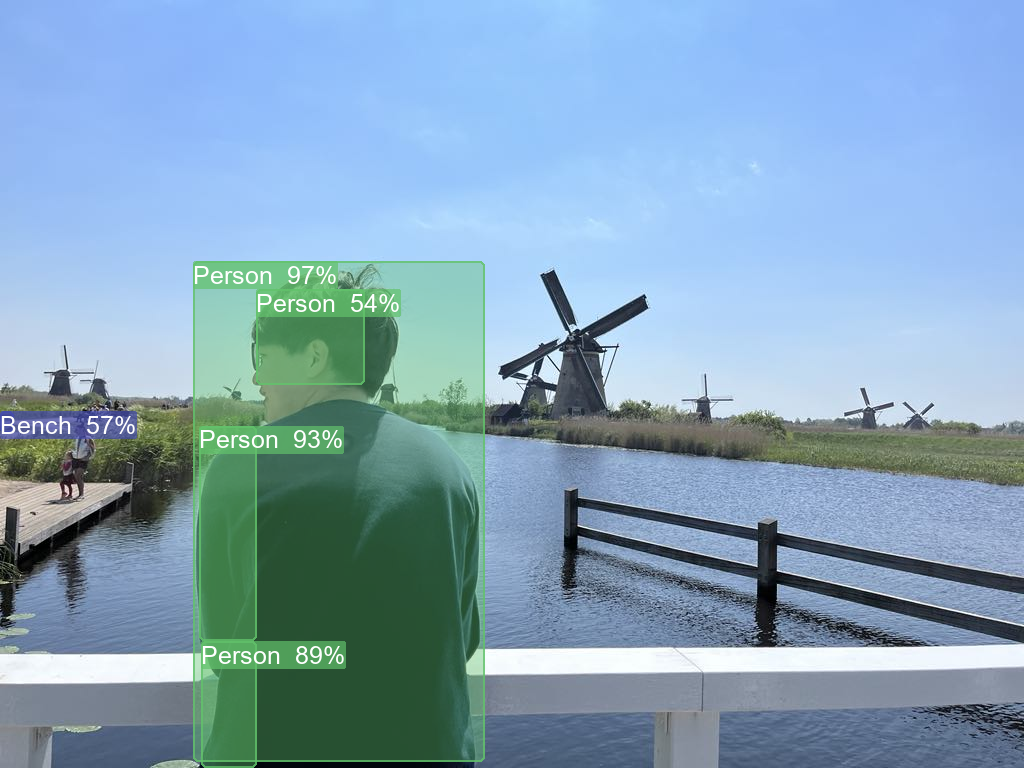

In [8]:
draw_bboxes(pil_image, predict_box, idx2label=cfg.dataset.class_list)